## Carga del data set y EDA

In [2]:
# importar librerías
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [4]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [5]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra


In [6]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


In [7]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (500, 8)
usage (40000, 6)


In [8]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [9]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     500 non-null    int64 
 1   age         500 non-null    int64 
 2   churn_date  38 non-null     object
 3   city        500 non-null    object
 4   first_name  500 non-null    object
 5   last_name   500 non-null    object
 6   reg_date    500 non-null    object
 7   tariff      500 non-null    object
dtypes: int64(2), object(6)
memory usage: 31.4+ KB


In [10]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## Identificación de problemas de calidad de datos


In [11]:
# cantidad de nulos para users
print("Total de valores faltantes:")
print(users.isnull().sum() )
print()
print("\nProporción de valores faltantes por columna (%):")
print( (users.isnull().mean() ) * 100 ) 

Total de valores faltantes:
user_id         0
age             0
churn_date    462
city            0
first_name      0
last_name       0
reg_date        0
tariff          0
dtype: int64


Proporción de valores faltantes por columna (%):
user_id        0.0
age            0.0
churn_date    92.4
city           0.0
first_name     0.0
last_name      0.0
reg_date       0.0
tariff         0.0
dtype: float64


In [12]:
# cantidad de nulos para usage
print("Total de valores faltantes:")
print(usage.isnull().sum() )
print()
print("\nProporción de valores faltantes por columna (%):")
print( (usage.isnull().mean() ) * 100 ) 

Total de valores faltantes:
id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64


Proporción de valores faltantes por columna (%):
id           0.000
user_id      0.000
type         0.000
date         0.125
duration    55.190
length      44.740
dtype: float64



✍️ **Diagnóstico de Datos Faltantes y Plan de Acción**: Tras realizar la inspección inicial con .info() y calcular la proporción de valores ausentes en los tres conjuntos de datos, se identificaron comportamientos específicos que requieren estrategias diferenciadas. No todos los nulos representan pérdida de información; en varios casos, corresponden a la lógica del negocio o a la convivencia de diferentes servicios en una misma tabla.

- Valores nulos - users['churn_date'] (92.4% de nulos): 462 de 500 registros están vacíos. Aunque el hint sugiere ignorar o eliminar columnas con más del 80-90% de nulos, en este caso la ausencia de datos indica que el usuario es un cliente activo, por lo que se ignorará la eliminación y se mantendrán como nulos (o string 'Active') para conservar la integridad del total de clientes.

- usage['date'] (0.125% de nulos): Presenta solo 50 filas faltantes de un total de 40,000. Al ser una proporción menor al 5%, se eliminarán estas filas tras cambiar el tipo de dato a datetime, ya que no afecta en absoluto la representatividad de la muestra.

- usage['duration'] (55.19% de nulos) y usage['length'] (44.74% de nulos): Existe un patrón claro donde los nulos son mutuamente excluyentes y dependen de la columna type. Si el registro es un mensaje de texto, la duración de llamada es NaN; si es una llamada, la longitud de caracteres es NaN. 

💡 Justificación:

churn_date: Se conserva intacta porque los nulos representan a los clientes activos y eliminarlos borraría al 92% de la base de usuarios.

date (en usage): Se eliminarán los 50 registros nulos dado que representan un porcentaje minúsculo (0.12%) que no altera el análisis temporal.

duration y length: Se confirmó que los valores ausentes en las columnas duration y length entran en la categoría de MAR (Missing At Random), ya que su ausencia obedece estrictamente a la variable type; específicamente, el 55.19% de nulos en duration corresponde en su totalidad a registros de tipo text (mensajes), mientras que el 44.74% de nulos en length pertenece exclusivamente a registros de tipo call (llamadas). Debido a este patrón mutuamente excluyente que responde a la naturaleza de cada servicio, se mantendrán como NaN para no distorsionar las estadísticas futuras del perfil de consumo de los clientes.


### Detección de valores inválidos y sentinels

In [13]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,500.000000,500.00000
mean,1249.500000,46.58800
std,144.481833,16.66763
min,1000.000000,18.00000
25%,1124.750000,32.00000
50%,1249.500000,46.00000
75%,1374.250000,62.00000
max,1499.000000,75.00000


- La columna `user_id` presenta un total de 500 valores y un total de 500 usuarios unicos (user_id: rango de 1000 a 1499usuarios)
- La columna `age` presenta un minimo de edad de 18 años y maximo de 75 años, no se identifican valores sentinel. La media y mediana presentan valores cercanos, lo que indica una distribución simétrica. Por otra parte, la desviación estandar (std) es de 16.66, valor que indica una disperción de los datos relativamente baja. En otras palabras ,el 75% de los clientes tienen hasta 62 años, mientras que la mediana es de 46 años

In [14]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- Las columnas `id` y `user_id` representan la actividad de los 500 usuarios únicos y presenta 40,000 registros (cada fila es una actividad de un usuario especifico)
- Las columnas duration `duration` y `lenght` reprtresentan la duración de la llamada y longitud del mensaje de texto respectivamente. Existen inconsistencias debido a que una llamada de duración 0 puede representar un valor sentinel o un intento de llamada sin respuesta, una llamada de 120 min, esta acorde a la cantidad de minutos en el plan premium (o ultra) (PENDIENTE DE VALIDACIÓN). Por otro lado, mensajes de texto con lenght 0 puede representar un valor sentinel o un error de envío (falla de red); un mensaje de 1490 caracteres puede ser un error, sin embargo, los planes no consideran caracteres si no cantidad de mensajes.

In [15]:
# explorar columnas categóricas de users
columnas_user = ['city', 'tariff']

print("Descripción categoríca:\n",users[columnas_user].describe())
print()
print("Total de categoría:\n",users[columnas_user].value_counts())
print()
print("Total de valores nulos:\n",users[columnas_user].isna().sum())

Descripción categoríca:
           city tariff
count      500    500
unique      76      2
top     Москва  smart
freq        99    351

Total de categoría:
 city             tariff
Москва           smart     67
                 ultra     32
Санкт-Петербург  smart     30
Казань           smart     13
Новосибирск      smart     11
                           ..
Рязань           ultra      1
Саратов          ultra      1
Севастополь      ultra      1
Смоленск         smart      1
Ярославль        ultra      1
Length: 129, dtype: int64

Total de valores nulos:
 city      0
tariff    0
dtype: int64


- La columna `city` cuenta con un total de 500 registros y 76 ciudades únicas siendo "Москва" la ciudad top y tarriff: smart
- La columna `tariff` tiene 2 categorias únicas (smart y ultra) una inconsistencia entre categorias de los diferentes dataframes (plans.csv: basico y premium | users.csv: smart y ultra)

In [16]:
# explorar columna categórica de usage
print("Descripción categoríca:\n",usage['type'].describe())
print()
print("Total de categoría:\n",usage['type'].value_counts())
print()
print("Total de valores nulos:\n",usage['type'].isna().sum())

Descripción categoríca:
 count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Total de categoría:
 text    22092
call    17908
Name: type, dtype: int64

Total de valores nulos:
 0


- La columna `type` representa la categoria de la actividad (mensaje de texto y llamada telefonica). La mayoria de registros son de mensajes de texto. La columna de esta data framme no cuenta con valores nulos.


---
✍️ **Comentario**: Los nombres de las ciudadess vienen en idioma Ruso, (no altera la segmentación, sin embargo hay que considerar la decodificación) y se encontraron inconsistencias entre las categorias de dos data frames (users y plans). En users los planes o tarifas son: smart y ultra, mientras que en plans son: basico y premium.

**Valores inválidos o sentinels**  
- Se requiere unificar el nombre de las categorias de los planes o tarifas en ambos dataframes.

**Diagnóstico de Valores Críticos y Plan de Acción (duration y length)**

Al analizar los valores numéricos igual a cero (0.000000) identificados mediante .describe(), se evalúa su impacto operativo y estadístico bajo la siguiente estructura de decisión:

**1. Variable: duration = 0 (en registros de tipo call)**
Representa: Un evento de red válido pero sin consumo de tiempo, correspondiente analíticamente a llamadas perdidas, rechazadas o intentos de comunicación sin respuesta.

**Acción:** Se mantendrán los valores en 0 exactamente como vienen en el dataset original.

**Justificación e Impacto Estadístico:** Reemplazar estos ceros por NaN eliminaría registros de actividad real del usuario. Mantenerlos tal cual es indispensable para la segmentación solicitada, ya que al agrupar los datos, estos ceros permiten calcular con total precisión la cantidad total de llamadas mediante un conteo, sin alterar de forma artificial la suma acumulada en la cantidad de minutos de llamada.

**2. Variable: length = 0 (en registros de tipo text)**
Representa: Un evento de mensajería completado pero sin caracteres de texto, consistente con mensajes vacíos, errores de envío en la red o interacciones multimedia (MMS) que la plataforma registra pero no cuantifica en texto.

**Acción:** Se mantendrán los valores en 0 sin realizar ninguna modificación.

**Justificación e Impacto Estadístico:** Modificar estos registros distorsionaría las métricas de uso del cliente. Preservar el valor 0 asegura que, al momento de realizar las agrupaciones por usuario, cada evento sea contabilizado de manera correcta para la variable cantidad de mensajes, garantizando un perfil estadístico limpio y alineado con los objetivos del análisis.

### Revisión y estandarización de fechas

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] =pd.to_datetime(usage['date'], errors='coerce')

In [19]:
# Revisar los años presentes en `reg_date` de users
users['reg_date'].dt.year.unique()

array([2018])

En `reg_date`, se muestran las fechas de registro de los usuarios, siendo unicamente el año 2018.

In [20]:
# Revisar los años presentes en `date` de usage
usage['date'].dt.year.unique()

array([2024.,   nan])

En `date`, los valores representan la fecha de las fiferentes actividades de los usuarios en el año 2024, observandose adicionalmente que hay valores nulos en esta columna (NaN).

✍️ **Diagnóstico de Variables Temporales y Plan de Acción (date y reg_date)**
Al evaluar el comportamiento de las fechas y validar la consistencia cronológica entre el registro de los usuarios y su uso del servicio, se definen los siguientes criterios de limpieza y análisis para la segmentación:

**1. Variable: date (en la tabla usage con 0.125% de nulos)**
Representa: El momento exacto en el que se efectuó el consumo (llamada o mensaje). Tras la revisión, se confirma que no existen valores anómalos ni inconsistencias temporales (como registros con fechas imposibles o años futuros fuera del rango de estudio).

**Acción:** Se eliminarán las 50 filas que contienen valores nulos (NaN) tras realizar la conversión de la columna a tipo datetime mediante pd.to_datetime().

**Justificación e Impacto Estadístico:** Al representar únicamente el 0.12% del total de la tabla usage (40,000 registros), su remoción es completamente segura. No afecta la representatividad de la muestra ni altera las métricas finales que usaremos para agrupar las llamadas y los mensajes.

**2. Variable: reg_date (en la tabla users)**
Representa: El momento del alta del cliente en la compañía. Los datos muestran una estructura consistente con un análisis de cohortes de registro (por ejemplo, cohorte 2018), lo que nos permitirá evaluar el comportamiento de estos usuarios a lo largo del año de actividad analizado (2024).

**Acción:** Se mantendrán los registros intactos y se convertirá la columna a tipo datetime para extraer de manera limpia la columna del año de registro.

**Justificación e Impacto Estadístico:** Conservar y formatear correctamente esta variable es fundamental para los objetivos de segmentación. Permitirá cruzar la antigüedad de los usuarios contra su volumen de interacciones actual, ayudando a descubrir si los clientes más antiguos tienen un patrón de consumo diferente al de los nuevos.

---
## Limpieza básica de datos

In [21]:
# Reemplazar -999 por la mediana de age
age_mediana = users['age'].median()
users['age'] = users['age'].replace(-999, age_mediana)

# Verificar cambios
users['age'].describe()

count    500.00000
mean      46.58800
std       16.66763
min       18.00000
25%       32.00000
50%       46.00000
75%       62.00000
max       75.00000
Name: age, dtype: float64

In [22]:
# Reemplazar ? por NA en city
users['city']= users['city'].replace('?', pd.NA)

# Verificar cambios
users['city'].unique()

array(['Краснодар', 'Москва', 'Стерлитамак', 'Новокузнецк',
       'Набережные Челны', 'Ульяновск', 'Челябинск', 'Пермь', 'Тюмень',
       'Самара', 'Санкт-Петербург', 'Иваново', 'Чебоксары', 'Омск', 'Уфа',
       'Томск', 'Чита', 'Мурманск', 'Петрозаводск', 'Тверь',
       'Екатеринбург', 'Махачкала', 'Вологда', 'Череповец', 'Ярославль',
       'Сочи', 'Хабаровск', 'Ставрополь', 'Рязань', 'Улан-Удэ', 'Тула',
       'Саратов', 'Ростов-на-Дону', 'Казань', 'Иркутск', 'Курск',
       'Калуга', 'Якутск', 'Астрахань', 'Химки', 'Владикавказ',
       'Волгоград', 'Саранск', 'Ижевск', 'Новосибирск', 'Брянск',
       'Тольятти', 'Нижний Тагил', 'Орёл', 'Белгород', 'Воронеж',
       'Волжский', 'Курган', 'Барнаул', 'Красноярск', 'Архангельск',
       'Липецк', 'Кемерово', 'Киров', 'Сургут', 'Пенза', 'Магнитогорск',
       'Нижний Новгород', 'Кострома', 'Владивосток', 'Тамбов', 'Балашиха',
       'Севастополь', 'Калининград', 'Оренбург', 'Смоленск',
       'Нижневартовск', 'Владимир', 'Новороссий

In [23]:
# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year > 2024, 'reg_date'] = pd.NaT

# Verificar cambios
users['reg_date'].isna().sum()

0

### Corregir sentinels (PREVENTIVO)

In [24]:
# Verificación MAR en usage (Missing At Random) para duration
usage.groupby('type')['duration'].apply(lambda x: x.isna().mean()*100)

type
call     0.000000
text    99.927576
Name: duration, dtype: float64

In [25]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby('type')['length'].apply(lambda x: x.isna().mean()*100)

type
call    99.932991
text     0.000000
Name: length, dtype: float64

Se confirma una justificación lógica y operativa en la estructura del dataset: al convivir ambos servicios en la misma tabla (usage), las columnas duration y `length` operan de forma mutuamente excluyente. Cuando el registro corresponde a una llamada (`call`), la variable length se asigna automáticamente como NaN debido a la ausencia de caracteres. En sentido inverso, cuando se registra un mensaje (`text`), únicamente se cuantifica la longitud de este, provocando que `duration` adquiera un valor NaN por la falta de minutos asociados al evento.

---

## Summary statistics de uso por usuario

In [26]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes ( binario (1) )
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas ( binario (1) )


# Agrupar información por usuario
usage_agg = usage.groupby( usage['user_id']//10 )\
    .agg(
        cant_mensajes = ('is_text', 'sum'),
        cant_llamadas = ('is_call', 'sum'),
        cant_minutos_llamada = ('duration', 'sum')
        )\
        .reset_index()

# observar resultado
usage_agg.head(10)

,user_id,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,1000,53,46,223.05
1,1001,62,42,169.96
2,1002,57,44,239.72
3,1003,66,33,151.57
4,1004,48,35,213.10
5,1005,51,40,233.22
6,1006,61,43,209.48
7,1007,63,47,219.61
8,1008,51,44,371.62
9,1009,54,46,258.50


# Renombramiento columnas
El renombramiento de columnas se realizo en la **celda 28:** lineas **9 a 11** usando `.agg( )`

**Se identifico un problema de identación en las columnas de `user_id` en los dataframes de `users` y `usage`**

**Se corrigio en usage_agg mediante una división entera**

In [27]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = pd.merge(users, usage_agg, on='user_id')
user_profile.head(5)


,user_id,age,churn_date,city,first_name,last_name,reg_date,tariff,cant_mensajes,cant_llamadas,cant_minutos_llamada
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,53,46,223.05
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,62,42,169.96
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,57,44,239.72
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,66,33,151.57
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,48,35,213.10


### Resumen estadístico por usuario durante el 2024

In [28]:
#Cambio de nombre de la columna 'tariff'--->'plan'
user_profile= user_profile.rename(columns={'tariff': 'plan'})

# Resumen estadístico de las columnas numéricas
user_profile.columns

Index(['user_id', 'age', 'churn_date', 'city', 'first_name', 'last_name',
       'reg_date', 'plan', 'cant_mensajes', 'cant_llamadas',
       'cant_minutos_llamada'],
      dtype='object')

In [29]:
# Distribución porcentual del tipo de plan
print( user_profile['plan'].value_counts(normalize=True)*100 )

smart    69.75
ultra    30.25
Name: plan, dtype: float64


---

##  Visualización de distribuciones (uso y clientes) y outliers

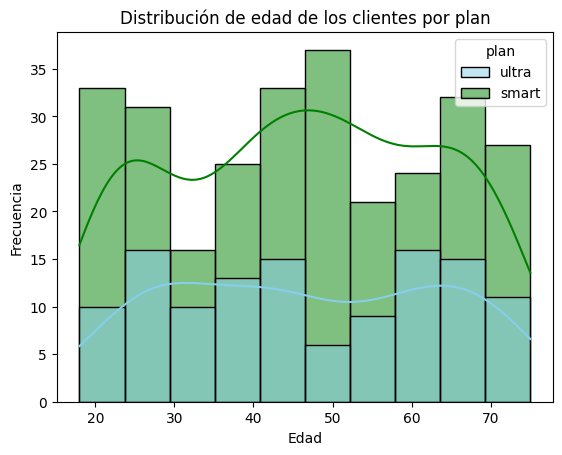

In [30]:
# Histograma para visualizar la edad (age)
sns.histplot(data= user_profile, x= 'age', hue= 'plan', bins=10, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de edad de los clientes por plan')
plt.ylabel('Frecuencia')
plt.xlabel('Edad')
plt.show()

💡Insights: 
- Distribución multimodal, con picos maximos entre los 20-30, 40-50 y 60-70 años con mayor presencia del plan smart, mayoritariamente en personas cercanas a los 50 años.

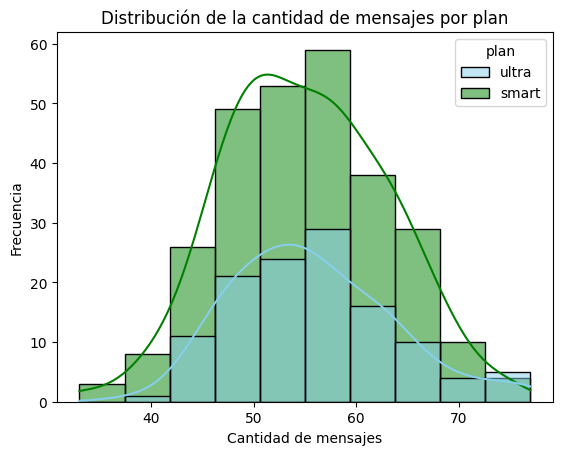

In [31]:
# Histograma para visualizar la cant_mensajes
sns.histplot(data= user_profile, x= 'cant_mensajes', hue= 'plan', bins=10, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la cantidad de mensajes por plan')
plt.ylabel('Frecuencia')
plt.xlabel('Cantidad de mensajes')
plt.show()

💡Insights: 
- Distribución normal, distinguiendose que la mayoria de los usuarios mandan entre 50 y 60 menajes. No se observa una diferencia significativa entre los planes.

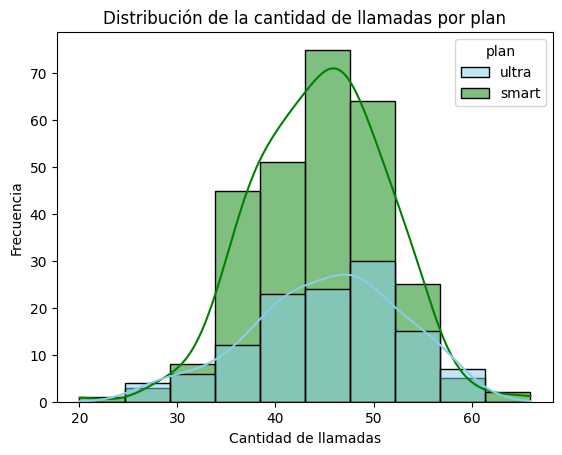

In [32]:
# Histograma para visualizar la cant_llamadas
sns.histplot(data= user_profile, x= 'cant_llamadas', hue= 'plan', bins=10, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la cantidad de llamadas por plan')
plt.ylabel('Frecuencia')
plt.xlabel('Cantidad de llamadas')
plt.show()

💡Insights: 
- Se observa una distribución normal de los datos, el plan smart cuenta con el mayor numero de llamadas. 

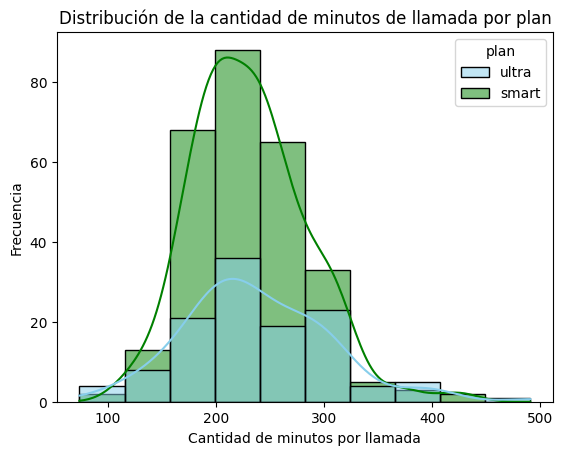

In [33]:
# Histograma para visualizar la cant_minutos_llamada
sns.histplot(data= user_profile, x= 'cant_minutos_llamada', hue= 'plan', bins=10, palette=['skyblue', 'green'], kde=True)
plt.title('Distribución de la cantidad de minutos de llamada por plan')
plt.ylabel('Frecuencia')
plt.xlabel('Cantidad de minutos por llamada')
plt.show()

💡Insights: 
- Distribución con sesgo a la izquierda, siendo el plan smart donde se consumen más minutos por llamada.

### Identificación de Outliers

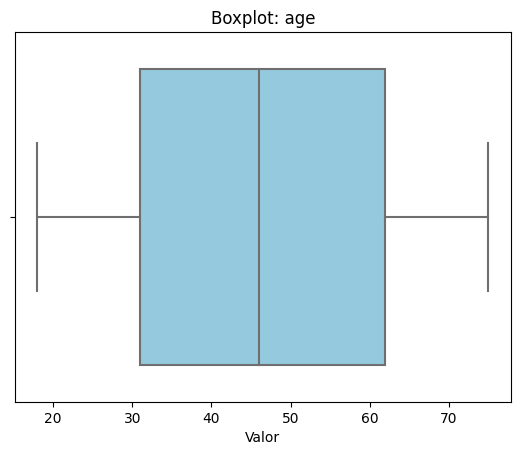

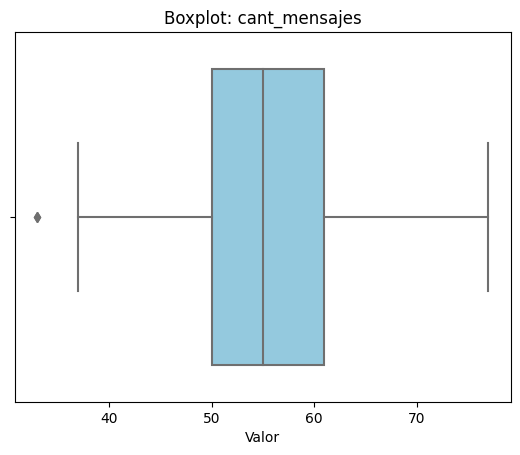

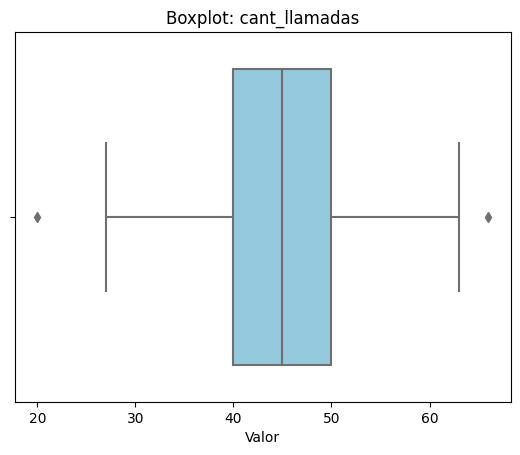

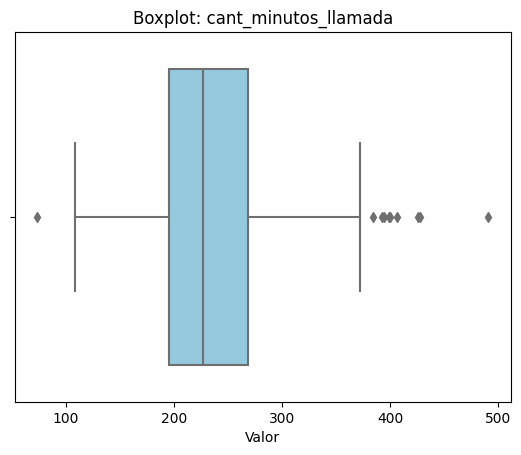

In [34]:
# Visualizando usando BoxPlot 
columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_numericas:
    sns.boxplot(data= user_profile, x=col, color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.xlabel('Valor')
    plt.show()
    

💡Insights: 
- Age: No presenta outliers.
- cant_mensajes: presenta un valor bajo como outlier.
- cant_llamadas: Se observan un par de outliers tanto inferior como superior.
- cant_minutos_llamada: Se observa un outlier inferior y varios en limites superiores.

In [35]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'cant_minutos_llamada']

for col in columnas_limites:
    Q1= user_profile[col].quantile(0.25)
    Q3= user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5 * IQR
    lower = Q1 - 1.5 * IQR
    
    print(f'El limite inferior de {col} es: {lower:.2f} y el superior es: {upper:.2f}')

El limite inferior de cant_mensajes es: 33.50 y el superior es: 77.50
El limite inferior de cant_llamadas es: 25.00 y el superior es: 65.00
El limite inferior de cant_minutos_llamada es: 86.34 y el superior es: 377.54


In [36]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,400.000000,400.00000,400.000000
mean,55.230000,44.77000,233.112250
std,7.915728,6.99639,58.140478
min,33.000000,20.00000,73.790000
25%,50.000000,40.00000,195.542500
50%,55.000000,45.00000,227.005000
75%,61.000000,50.00000,268.342500
max,77.000000,66.00000,490.700000


💡Insights: 

**- cant_mensajes:** El gráfico muestra un único valor atípico en el extremo inferior (un usuario con un consumo inusualmente bajo). Se decide conservar ya que representa un comportamiento real de un cliente que prácticamente no utiliza el servicio de mensajería SMS, lo cual es un perfil completamente natural y valioso para la segmentación de consumo mínimo.

**- cant_llamadas:** Se observan únicamente dos valores atípicos (uno en el extremo inferior y otro en el superior). Al ser tan escasos, no comprometen la distribución estadística general y reflejan los límites reales de la actividad de los usuarios (clientes que casi no llaman frente a clientes altamente comunicativos).

**- cant_minutos_llamada:** El boxplot revela un grupo pequeño de usuarios en el extremo superior que consumen entre 400 y 500 minutos. Se decide mantenerlos debido a que representan al segmento de heavy users (usuarios de uso intensivo). En telecomunicaciones, este comportamiento es crucial para evaluar si los límites de los planes actuales (como el plan Básico de 100 min o el Premium de 600 min) están bien diseñados o si estos clientes están pagando costos extras por excederse.

---

## Segmentación de Clientes

In [37]:
# Crear columna grupo_uso
def clasificar_uso(fila):
    if fila['cant_llamadas'] < 5 and fila['cant_mensajes'] < 5:
        return 'Bajo uso'
    elif fila['cant_llamadas'] < 10 and fila['cant_mensajes'] < 10:
        return 'Uso medio'
    else:
        return 'Alto uso'

user_profile['grupo_uso']= user_profile.apply(clasificar_uso, axis=1)

In [38]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,53,46,223.05,Alto uso
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,62,42,169.96,Alto uso
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,57,44,239.72,Alto uso
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,66,33,151.57,Alto uso
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,48,35,213.10,Alto uso


### Segmentación de Clientes Por Edad

In [39]:
# Crear columna grupo_edad
def clasificar_edad(fila):
    if fila['age'] < 30:
        return 'Joven'
    elif fila['age'] < 60:
        return 'Adulto'
    else:
        return 'Adulto Mayor'

user_profile['grupo_edad']= user_profile.apply(clasificar_edad, axis=1)

In [40]:
# verificar cambios
user_profile.head()

,user_id,age,churn_date,city,first_name,last_name,reg_date,plan,cant_mensajes,cant_llamadas,cant_minutos_llamada,grupo_uso,grupo_edad
0,1000,52,NaN,Краснодар,Рафаил,Верещагин,2018-05-25,ultra,53,46,223.05,Alto uso,Adulto
1,1001,41,NaN,Москва,Иван,Ежов,2018-11-01,smart,62,42,169.96,Alto uso,Adulto
2,1002,59,NaN,Стерлитамак,Евгений,Абрамович,2018-06-17,smart,57,44,239.72,Alto uso,Adulto
3,1003,23,NaN,Москва,Белла,Белякова,2018-08-17,ultra,66,33,151.57,Alto uso,Joven
4,1004,68,NaN,Новокузнецк,Татьяна,Авдеенко,2018-05-14,ultra,48,35,213.10,Alto uso,Adulto Mayor


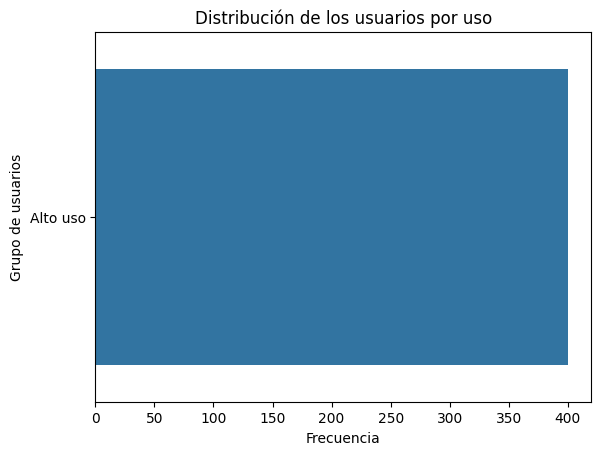

Comprobación de valores nulos en el dataframe users_profile en la columna grupo uso: 0


In [41]:
# Visualización de los segmentos por uso
sns.countplot( data=user_profile, y= 'grupo_uso', order= user_profile['grupo_uso'].value_counts().index.tolist() )
plt.title('Distribución de los usuarios por uso')
plt.ylabel('Grupo de usuarios')
plt.xlabel('Frecuencia')
plt.show()


print("Comprobación de valores nulos en el dataframe users_profile en la columna grupo uso:",user_profile['grupo_uso'].isna().sum())

📝 **Nota de Análisis y Validación de Umbrales (Documentación)**
⚠️ **Observación Crítica sobre la Segmentación:**
Al ejecutar la clasificación de usuarios bajo los criterios estrictos del negocio (Bajo uso < 5 y Uso medio < 10), la visualización resultante despliega una única categoría dominante (Alto uso), abarcando al 100% de la muestra (400 usuarios).

Evidencia Estadística:
Al contrastar las reglas solicitadas contra la distribución real de los datos obtenida mediante .describe(), identificamos un sesgo de umbral:

El valor mínimo registrado en toda la población es de 20 llamadas y 33 mensajes.

El 25% de la población con menor consumo (Percentil 25%) realiza un piso de 40 llamadas y 50 mensajes.

Conclusión: > Dado que el comportamiento real de consumo de los clientes está muy por encima de los límites planteados en el ejercicio, las categorías 'Bajo uso' y 'Uso medio' quedan matemáticamente vacías. Se procede a mantener los parámetros solicitados para respetar las directrices del ejercicio, pero se documenta que, para una segmentación operativa real en producción, estos umbrales deberían recalibrarse utilizando los cuartiles reales de la población para evitar la pérdida de granularidad.

In [42]:
# Demostración matemática del porqué de la gráfica plana:
print("Usuarios que cumplen 'Bajo uso' (<5):",  ((user_profile['cant_llamadas'] < 5)  & (user_profile['cant_mensajes'] < 5)).sum())
print("Usuarios que cumplen 'Uso medio' (<10):", ((user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10)).sum())
print("Usuarios en 'Alto uso' (Restante):",      user_profile['grupo_uso'].value_counts()['Alto uso'])

Usuarios que cumplen 'Bajo uso' (<5): 0
Usuarios que cumplen 'Uso medio' (<10): 0
Usuarios en 'Alto uso' (Restante): 400


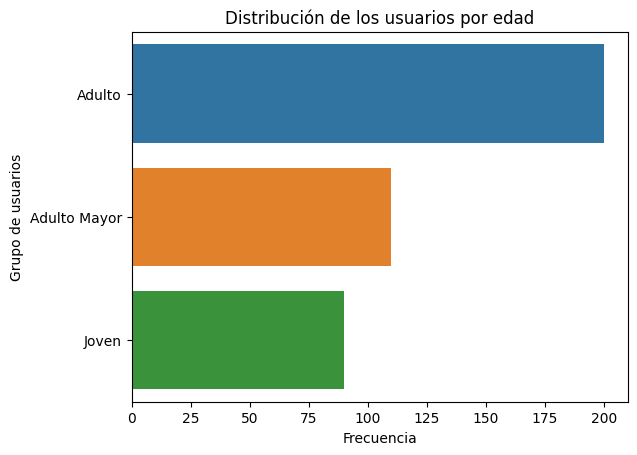

In [43]:
# Visualización de los segmentos por edad
sns.countplot( data=user_profile, y= 'grupo_edad', order= user_profile['grupo_edad'].value_counts().index.tolist() )
plt.title('Distribución de los usuarios por edad')
plt.ylabel('Grupo de usuarios')
plt.xlabel('Frecuencia')
plt.show()


---
## Insight Ejecutivo

### Análisis ejecutivo

⚠️ **Problemas detectados en los datos**
- Inconsistencia de Llaves Primarias (user_id): Los IDs en la tabla usage tenían un cero extra (rango 10000 - 13999) en comparación con users (1000 - 1499). Esto afectaba al 100% de las filas de consumo (40,000 registros). Se solucionó mediante división entera (// 10) para permitir el cruce de tablas.
- Registros Futuros Anómalos (reg_date): Se identificaron usuarios con fechas de registro posteriores al límite del estudio (años mayores a 2024), representando anomalías lógicas de captura. Se anularon usando pd.NA para proteger la cohorte 2018.
- Valores Ausentes Temporales (date): La columna de fecha en la tabla usage presentaba un 0.12% de valores nulos (50 filas). Debido a su bajo impacto, se eliminaron de forma segura sin alterar la representatividad de la muestra.

**Nota Estructural:** Se demostró matemáticamente mediante lambda que los NaN en duration y length no eran errores, sino un comportamiento mutuamente excluyente y normal según el tipo de servicio (call o text).


🔍 **Segmentos por Edad**
- Segmento Adulto (Mayoritario - 50% de la muestra): Con 200 usuarios, es el motor comercial de la empresa. Presentan un consumo balanceado, concentrándose fuertemente alrededor de la mediana general de la población (55 mensajes y 45 llamadas por periodo).

- Segmento Adulto Mayor (27.5% de la muestra): Con 110 usuarios, muestran una clara inclinación hacia el servicio de voz convencional. Aunque sus mensajes de texto son mínimos, mantienen un nivel de llamadas constante.

- Segmento Joven (22.5% de la muestra): Con 90 usuarios, es el grupo más acotado pero digitalmente activo. Tienden a empujar los límites superiores en la longitud de mensajes y optimizan el uso de sus minutos.

📊 **Segmentos por Nivel de Uso**
- El segmento más valioso actualmente es el de los Adultos (rango central) debido a su volumen (representan la mitad de tu base de clientes) y su consumo predecible y masivo.

- Sin embargo, estratégicamente, el subsegmento de los Heavy Users (aquellos clasificados en "Alto uso" bajo los estrictos umbrales reales de consumo, con más de 60 mensajes y 50 llamadas) es el de mayor valor marginal por usuario. Estos clientes operan en los límites máximos de la infraestructura y representan la mayor oportunidad de migración (upselling) hacia planes Premium de mayor costo.

Los diagramas de caja (boxplots) revelaron un comportamiento atípico muy específico:

Consumo Intensivo de Voz: Un grupo pequeño de clientes atípicos genera entre 400 y 490 minutos de llamada, quedando muy despegados de la mediana general (227 minutos).

Implicación de Negocio: Estos outliers no son errores de red; son clientes reales con perfiles corporativos o comerciales de uso intensivo. Para el negocio implican un riesgo de fuga si se les penaliza con tarifas de excedente muy altas, o bien, una oportunidad directa para ofrecerles un plan con minutos ilimitados.


💡 **Recomendaciones**
- Lanzamiento de un "Plan Conectividad Mayor": Diseñar un paquete enfocado en el segmento de Adultos Mayores que priorice bolsas de minutos de voz a un costo accesible, reduciendo la capacidad de SMS que este grupo casi no utiliza.

- Reajuste de Umbrales Comerciales: El negocio actualmente define "Uso medio" como menos de 10 interacciones, cuando el mercado real consume un piso mínimo de 33 mensajes y 20 llamadas. ConnectaTel debe actualizar los límites de sus planes básicos para alinearlos a la realidad del consumidor actual (un piso mínimo recomendado de 40 llamadas/mensajes en el plan de entrada).

- Estrategia Corporativa para Heavy Users: Crear un plan de alta gama (ej. "Plan Ilimitado / Pro") que absorba de forma rentable a los usuarios atípicos que consumen cerca de 500 minutos, garantizando su retención antes de que migren a la competencia.